# Problem Set 3

### Question 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class AdChannelBandit:
    """K-armed bandit for ad channel selection with Bernoulli rewards."""
    
    def __init__(self):
        self.channels = ["Email", "Social Media", "Display Ads", "Search", "Influencer"]
        self.K = len(self.channels)
        self._rates = np.array([0.08, 0.15, 0.12, 0.25, 0.05])
    
    def pull(self, arm):
        """Select a channel and observe conversion (1) or not (0)."""
        return np.random.binomial(1, self._rates[arm])
    
    def optimal_arm(self):
        """Index of the channel with the highest true conversion rate."""
        return np.argmax(self._rates)
    
    def expected_reward(self, arm):
        """True conversion rate of the given channel (used for regret calculation)."""
        return self._rates[arm]

bandit = AdChannelBandit()
print("Channels:", bandit.channels)
print(f"Number of arms (K): {bandit.K}")

Channels: ['Email', 'Social Media', 'Display Ads', 'Search', 'Influencer']
Number of arms (K): 5


#### (1a) Run the random policy and plot cumulative reward and cumulative regret

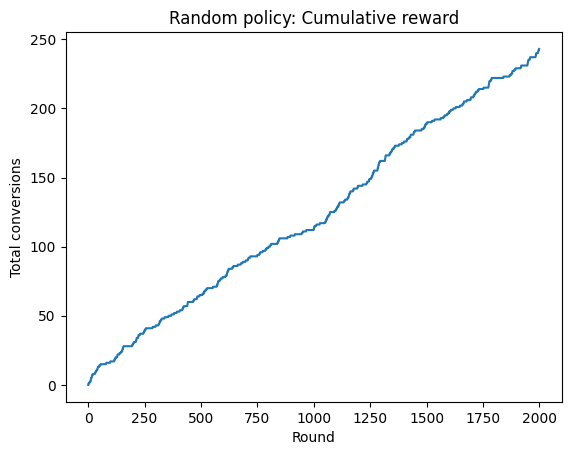

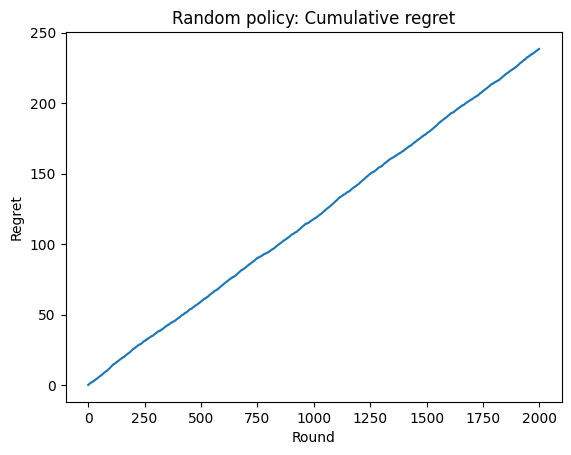

In [3]:
def run_random(bandit, T=2000):
    rewards = np.zeros(T, dtype=int)
    arms_played = np.zeros(T, dtype=int)
    for t in range(T):
        a = np.random.randint(bandit.K)
        arms_played[t] = a
        rewards[t] = bandit.pull(a)

    return rewards, arms_played

def cumulative_regret(bandit, arms_played):
    p_star = np.max(bandit._rates)
    regrets = np.array([p_star - bandit.expected_reward(a) for a in arms_played])
    return np.cumsum(regrets)

bandit = AdChannelBandit()
rewards, arms = run_random(bandit, T=2000)

plt.figure()
plt.plot(np.cumsum(rewards))
plt.title("Random policy: Cumulative reward")
plt.xlabel("Round")
plt.ylabel("Total conversions")
plt.show()

plt.figure()
plt.plot(cumulative_regret(bandit, arms))
plt.title("Random policy: Cumulative regret")
plt.xlabel("Round")
plt.ylabel("Regret")
plt.show()

#### (1b) Implement the following three bandit algorithms and compare them (plus the random baseline) on a single cumulative regret plot over $T = 2000$ rounds, averaged over 50 independent runs.

In [4]:
def epsilon_greedy(bandit, T=2000, epsilon=0.1):
    K = bandit.K
    rewards = np.zeros(T, dtype=int)
    arms_played = np.zeros(T, dtype=int)

    counts = np.zeros(K, dtype=int)
    means = np.zeros(K, dtype=float)

    for t in range(T):
        if np.random.rand() < epsilon:
            a = np.random.randint(K)
        else:
            a = int(np.argmax(means))

        r = bandit.pull(a)
        rewards[t] = r
        arms_played[t] = a

        counts[a] += 1
        means[a] += (r - means[a]) / counts[a]

    return rewards, arms_played

In [5]:
def ucb1(bandit, T=2000, c=2.0):
    K = bandit.K
    rewards = np.zeros(T, dtype=int)
    arms_played = np.zeros(T, dtype=int)

    counts = np.zeros(K, dtype=int)
    means = np.zeros(K, dtype=float)

    # pull each arm once
    t = 0
    for a in range(K):
        if t >= T:
            break
        r = bandit.pull(a)
        rewards[t] = r
        arms_played[t] = a
        counts[a] = 1
        means[a] = r
        t += 1

    # main loop
    for t0 in range(t, T):
        # use t0+1 as "t" in log to avoid log(0)
        t_for_log = t0 + 1
        bonus = c * np.sqrt(np.log(t_for_log) / counts)
        ucb = means + bonus
        a = int(np.argmax(ucb))

        r = bandit.pull(a)
        rewards[t0] = r
        arms_played[t0] = a

        counts[a] += 1
        means[a] += (r - means[a]) / counts[a]

    return rewards, arms_played

In [6]:
def thompson_sampling(bandit, T=2000):
    K = bandit.K
    rewards = np.zeros(T, dtype=int)
    arms_played = np.zeros(T, dtype=int)

    alpha = np.ones(K, dtype=float)
    beta = np.ones(K, dtype=float)

    for t in range(T):
        theta = np.random.beta(alpha, beta)
        a = int(np.argmax(theta))

        r = bandit.pull(a)
        rewards[t] = r
        arms_played[t] = a

        alpha[a] += r
        beta[a] += (1 - r)

    return rewards, arms_played

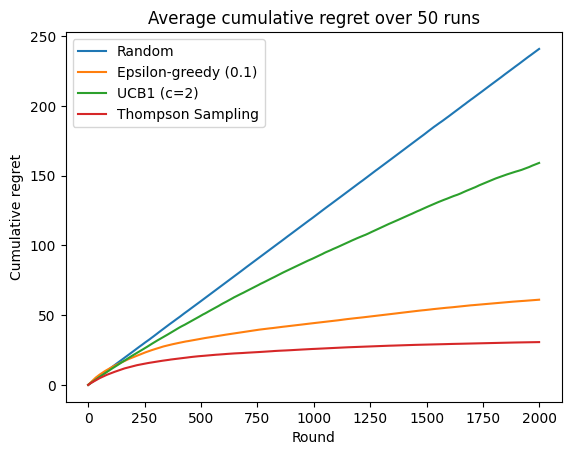

In [7]:
def average_cum_regret(alg_fn, bandit_class, T=2000, n_runs=50, **kwargs):
    all_curves = np.zeros((n_runs, T), dtype=float)
    for i in range(n_runs):
        bandit = bandit_class()
        _, arms = alg_fn(bandit, T=T, **kwargs)
        all_curves[i] = cumulative_regret(bandit, arms)
    return all_curves.mean(axis=0)

T = 2000
n_runs = 50

avg_rand = average_cum_regret(run_random, AdChannelBandit, T=T, n_runs=n_runs)
avg_eps  = average_cum_regret(epsilon_greedy, AdChannelBandit, T=T, n_runs=n_runs, epsilon=0.1)
avg_ucb  = average_cum_regret(ucb1, AdChannelBandit, T=T, n_runs=n_runs, c=2.0)
avg_ts   = average_cum_regret(thompson_sampling, AdChannelBandit, T=T, n_runs=n_runs)

plt.figure()
plt.plot(avg_rand, label="Random")
plt.plot(avg_eps, label="Epsilon-greedy (0.1)")
plt.plot(avg_ucb, label="UCB1 (c=2)")
plt.plot(avg_ts, label="Thompson Sampling")
plt.title("Average cumulative regret over 50 runs")
plt.xlabel("Round")
plt.ylabel("Cumulative regret")
plt.legend()
plt.show()

#### (1c) Answer the questions based on results in (1b)

(c1) Thompson Sampling learns the fastest, achieving the lowest cumulative regret. By maintaining a posterior distribution over each arm’s conversion rate, it balances exploration and exploitation more efficiently, focusing quickly on the best channel. In contrast, ε-greedy wastes rounds on random exploration and UCB1 explores more conservatively, leading to higher regret.

(c2) Testing each of the five channels uniformly for 400 rounds yields an expected regret of 2000(0.25−0.13)=240, since the average conversion rate during testing is 0.13 and no rounds remain to exploit the best channel. Adaptive algorithms perform better because they identify the superior channel early and allocate more future rounds to it, reducing regret growth over time.

### Question 2

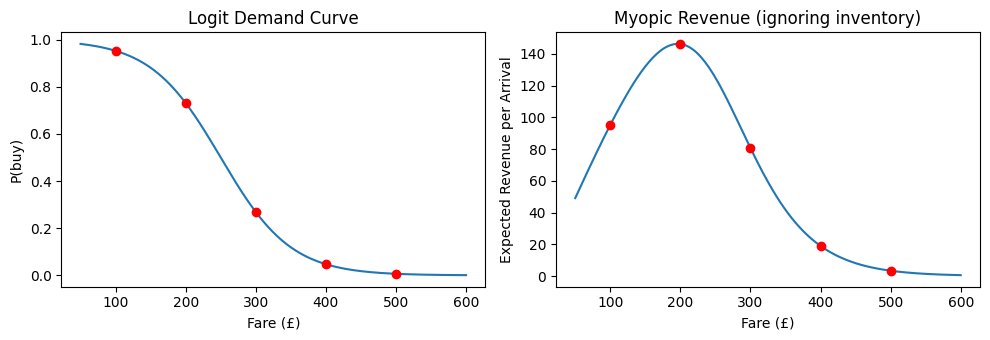

Observation space: MultiDiscrete([11 26])
Action space:      Discrete(5)  (fares = [100 200 300 400 500])
Purchase probs:    {np.int64(100): np.float64(0.953), np.int64(200): np.float64(0.731), np.int64(300): np.float64(0.269), np.int64(400): np.float64(0.047), np.int64(500): np.float64(0.007)}


In [8]:
import gymnasium
from gymnasium import spaces

class AirlinePricingEnv(gymnasium.Env):
    """Airline revenue management environment.

    State: (seats_remaining, days_to_departure)
    Action: one of 5 fare classes
    Reward: fare if passenger buys, 0 otherwise
    Terminal: departure day reached or sold out

    Default: 10 seats, 25 days (small state space so Q-learning can match VI well).
    """

    def __init__(self, max_seats=10, max_days=25, alpha=5.0, beta=-0.02):
        super().__init__()
        self.max_seats = max_seats
        self.max_days = max_days
        self.alpha = alpha
        self.beta = beta
        self.fares = np.array([100, 200, 300, 400, 500])

        self.observation_space = spaces.MultiDiscrete([max_seats + 1, max_days + 1])
        self.action_space = spaces.Discrete(len(self.fares))

    def demand_prob(self, price):
        """P(buy) = 1 / (1 + exp(-(alpha + beta * price)))"""
        return 1.0 / (1.0 + np.exp(-(self.alpha + self.beta * price)))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.seats_remaining = self.max_seats
        self.days_to_departure = self.max_days
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([self.seats_remaining, self.days_to_departure])

    def step(self, action):
        price = self.fares[action]

        if self.seats_remaining > 0:
            p = self.demand_prob(price)
            bought = int(self.np_random.binomial(1, p))
            reward = float(price * bought)
            self.seats_remaining -= bought
        else:
            reward = 0.0

        self.days_to_departure -= 1
        terminated = (self.days_to_departure == 0) or (self.seats_remaining == 0)
        truncated = False

        return self._get_obs(), reward, terminated, truncated, {}

env = AirlinePricingEnv()

price_grid = np.linspace(50, 600, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(price_grid, env.demand_prob(price_grid))
axes[0].scatter(env.fares, env.demand_prob(env.fares), c='red', zorder=5)
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('P(buy)')
axes[0].set_title('Logit Demand Curve')

axes[1].plot(price_grid, price_grid * env.demand_prob(price_grid))
axes[1].scatter(env.fares, env.fares * env.demand_prob(env.fares), c='red', zorder=5)
axes[1].set_xlabel('Fare (£)')
axes[1].set_ylabel('Expected Revenue per Arrival')
axes[1].set_title('Myopic Revenue (ignoring inventory)')
plt.tight_layout()
plt.show()

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}  (fares = {env.fares})")
print(f"Purchase probs:    {dict(zip(env.fares, np.round(env.demand_prob(env.fares), 3)))}")

#### (2a)

**1. State Space $\mathcal{S}$**
A state is defined by two variables:
$$s = (\text{seats\_remaining},\ \text{days\_to\_departure}), \quad \text{seats\_remaining} \in \{0,\dots,10\},\quad \text{days\_to\_departure} \in \{0,\dots,25\}$$
Therefore $|\mathcal{S}| = 11 \times 26 = 286$.

**2. Action Space $\mathcal{A}$**
The agent chooses a fare from five discrete classes:
$$\mathcal{A} = \{\pounds100,\ \pounds200,\ \pounds300,\ \pounds400,\ \pounds500\}, \quad |\mathcal{A}| = 5$$

**3. Reward $R(s,a)$**
Each period, one potential passenger arrives and buys with probability $p(a) = \frac{1}{1+\exp(-(\alpha+\beta\cdot\text{price}(a)))}$. The expected immediate reward is:
$$R(s,a) = \text{price}(a) \cdot p(a) = \frac{\text{price}(a)}{1+\exp(-(\alpha+\beta\cdot\text{price}(a)))}$$
If $\text{seats\_remaining} = 0$, then $R(s,a) = 0$ regardless of action.

**4. Transition $P(s'\mid s,a)$**
From state $s=(n,t)$ with $n>0$, the next state is $s'=(n', t-1)$ where $n'=n-1$ with probability $p(a)$ (passenger buys), and $n'=n$ with probability $1-p(a)$ (no purchase). If $n=0$, then $s'=(0,\,t-1)$ with probability 1.

**5. Discount Factor $\gamma$**
Since the horizon is finite ($T=25$ days), we set $\gamma=1$: all revenues within the episode are equally valuable and there is no need for time-value discounting. The finite horizon itself ensures the Bellman equation is well-defined.

**6. Episode Termination**
An episode terminates when $\text{days\_to\_departure}=0$ (the flight departs) or $\text{seats\_remaining}=0$ (the aircraft is fully sold).

#### (2b) Value iteration

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def value_iteration(env, gamma=0.99, tol=1e-6):
    """
    Compute optimal V and policy by value iteration.

    Returns:
        V: np.array shape (max_seats+1, max_days+1)
        policy: np.array shape (max_seats+1, max_days+1), optimal action index
    """
    max_seats = env.max_seats
    max_days = env.max_days
    n_actions = env.action_space.n  # 5

    V = np.zeros((max_seats + 1, max_days + 1), dtype=float)
    policy = np.zeros((max_seats + 1, max_days + 1), dtype=int)

    # Purchase probability depends only on price, so precompute once
    p_buy = np.array([env.demand_prob(price) for price in env.fares], dtype=float)

    while True:
        delta = 0.0
        V_new = V.copy()

        for s in range(max_seats + 1):
            for d in range(max_days + 1):
                # terminal states
                if s == 0 or d == 0:
                    V_new[s, d] = 0.0
                    policy[s, d] = 0
                    continue

                best_val = -1e18
                best_a = 0

                for a in range(n_actions):
                    price = env.fares[a]
                    p = p_buy[a]

                    # if bought -> reward=price, next state (s-1, d-1)
                    # if not bought -> reward=0, next state (s, d-1)
                    val = p * (price + gamma * V[s-1, d-1]) + (1 - p) * (gamma * V[s, d-1])

                    if val > best_val:
                        best_val = val
                        best_a = a

                V_new[s, d] = best_val
                policy[s, d] = best_a
                delta = max(delta, abs(V_new[s, d] - V[s, d]))

        V = V_new
        if delta < tol:
            break

    return V, policy

def plot_policy_heatmap(env, policy, title="Optimal Fare Heatmap"):
    fare_map = env.fares[policy]
    plt.figure(figsize=(7,5))
    plt.imshow(fare_map, origin="lower", aspect="auto")
    plt.colorbar(label="Fare")
    plt.xlabel("Days to departure")
    plt.ylabel("Seats remaining")
    plt.title(title)
    plt.tight_layout()
    plt.show()

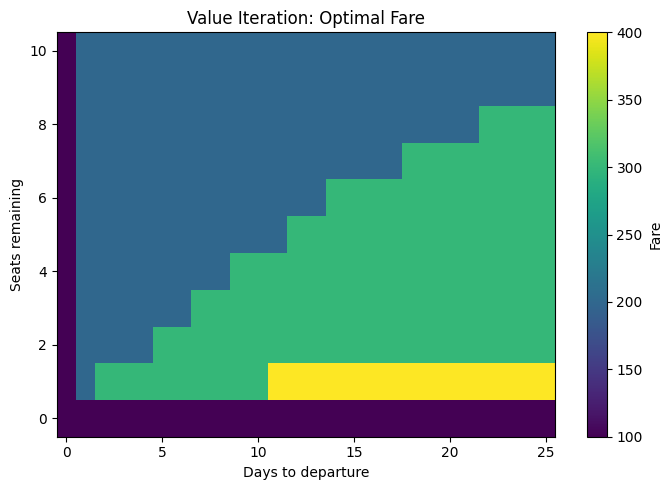

In [14]:
env = AirlinePricingEnv()
V_opt, pol_vi = value_iteration(env, gamma=0.99, tol=1e-6)
plot_policy_heatmap(env, pol_vi, "Value Iteration: Optimal Fare")

#### (2c) Tabular Q-learning

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def q_learning(env, n_episodes=10000, alpha=0.1, gamma=0.99,
               epsilon_start=0.4, epsilon_end=0.01):
    """
    Tabular Q-learning with epsilon-greedy exploration.

    Returns:
        Q: dict mapping (seats, days, action) -> value
        episode_rewards: list of total reward per episode
    """
    n_actions = env.action_space.n

    # Q as dict with default 0
    Q = {}
    def get_q(s, d, a):
        return Q.get((s, d, a), 0.0)

    def set_q(s, d, a, val):
        Q[(s, d, a)] = val

    episode_rewards = []

    for ep in range(n_episodes):
        # decaying epsilon (linear schedule like in prompt)
        eps = max(epsilon_end, epsilon_start - ep / (n_episodes / 3))

        obs, _ = env.reset()
        s, d = int(obs[0]), int(obs[1])
        done = False
        total = 0.0

        while not done:
            # epsilon-greedy action selection
            if np.random.rand() < eps:
                a = np.random.randint(n_actions)
            else:
                # argmax_a Q(s,d,a)
                q_vals = [get_q(s, d, a0) for a0 in range(n_actions)]
                a = int(np.argmax(q_vals))

            next_obs, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            s2, d2 = int(next_obs[0]), int(next_obs[1])

            total += r

            # TD target
            if done:
                target = r
            else:
                next_q_vals = [get_q(s2, d2, a0) for a0 in range(n_actions)]
                target = r + gamma * np.max(next_q_vals)

            # Q update
            old = get_q(s, d, a)
            new = old + alpha * (target - old)
            set_q(s, d, a, new)

            s, d = s2, d2

        episode_rewards.append(total)

    return Q, episode_rewards


def moving_average(x, window=100):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

def plot_learning_curve(episode_rewards, window=100):
    smooth = moving_average(episode_rewards, window=window)
    plt.figure(figsize=(7,4))
    plt.plot(smooth)
    plt.xlabel("Episode")
    plt.ylabel(f"Total revenue (MA{window})")
    plt.title("Q-learning learning curve")
    plt.tight_layout()
    plt.show()

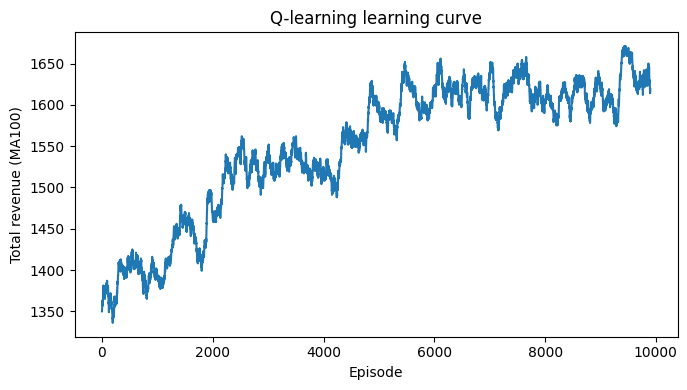

In [17]:
env = AirlinePricingEnv()
Q, ep_rewards = q_learning(env, n_episodes=10000, alpha=0.1, gamma=0.99,
                           epsilon_start=0.4, epsilon_end=0.01)
plot_learning_curve(ep_rewards, window=100)

#### (2d) Compare policies

In [18]:
def greedy_policy_from_Q(env, Q):
    max_seats = env.max_seats
    max_days = env.max_days
    n_actions = env.action_space.n

    def get_q(s, d, a):
        return Q.get((s, d, a), 0.0)

    policy = np.zeros((max_seats + 1, max_days + 1), dtype=int)

    for s in range(max_seats + 1):
        for d in range(max_days + 1):
            # terminal states: arbitrary action (0)
            if s == 0 or d == 0:
                policy[s, d] = 0
                continue
            q_vals = [get_q(s, d, a) for a in range(n_actions)]
            policy[s, d] = int(np.argmax(q_vals))

    return policy


def plot_side_by_side(env, policy_vi, policy_ql):
    fares_vi = env.fares[policy_vi]
    fares_ql = env.fares[policy_ql]

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    im0 = axes[0].imshow(fares_vi, origin="lower", aspect="auto")
    axes[0].set_title("Value Iteration policy (fare)")
    axes[0].set_xlabel("Days to departure")
    axes[0].set_ylabel("Seats remaining")
    fig.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(fares_ql, origin="lower", aspect="auto")
    axes[1].set_title("Q-learning greedy policy (fare)")
    axes[1].set_xlabel("Days to departure")
    axes[1].set_ylabel("Seats remaining")
    fig.colorbar(im1, ax=axes[1], fraction=0.046)

    plt.tight_layout()
    plt.show()

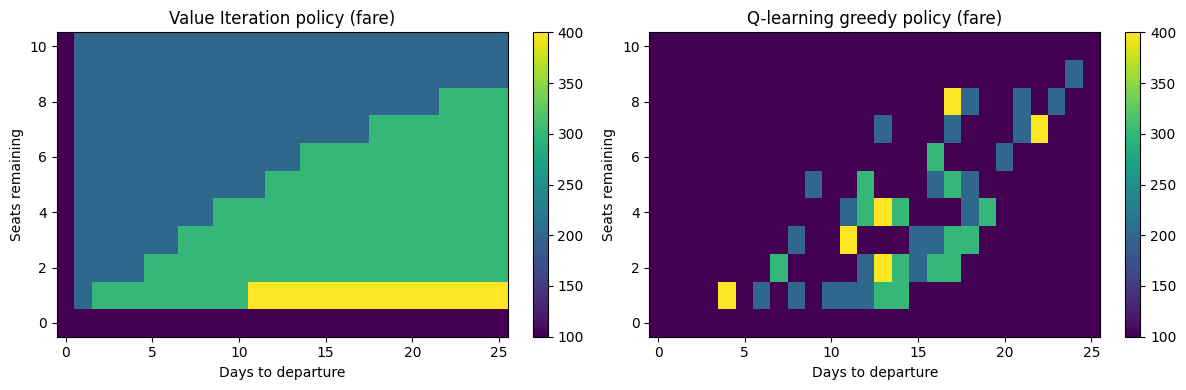

In [19]:
pol_ql = greedy_policy_from_Q(env, Q)
plot_side_by_side(env, pol_vi, pol_ql)

The greedy policy learned by Q-learning broadly matches the structure of the value-iteration policy: prices increase when seats become scarce or departure approaches, reflecting the higher opportunity cost of remaining inventory. However, the Q-learning heatmap is noisier and differs in some states, especially those that are rarely visited, because the agent learns from finite samples and exploration noise.

Value iteration is preferable when the demand model is known and the state space is small, since it computes the optimal policy directly and reliably. Q-learning is more useful when the model is unknown or too complex to specify, as it can learn from interaction data, though it requires sufficient training and careful exploration to approach optimal performance.

### Question 3

In [4]:
import gymnasium
import numpy as np
from gymnasium import spaces
from itertools import combinations
from scipy.special import expit

class ContentPersonalizationEnv(gymnasium.Env):
    """
    Within-session content personalisation.

    A platform displays K=3 of M=5 content categories at each page view.
    The visitor (one of 3 latent types) clicks according to an MNL model
    over the displayed categories plus an outside option.  At session end,
    conversion probability depends on how well displayed content matched
    the visitor's true preferences.
    """

    CATEGORIES = ["Tech", "Fashion", "Sports", "Food", "Travel"]
    TYPE_NAMES = ["Tech enthusiast", "Fashionista", "Sports fan"]
    TYPE_UTILITIES = np.array([
        [2.0, 0.2, 0.5, 0.3, 0.8],   # Type 0
        [0.3, 2.0, 0.2, 0.8, 1.0],   # Type 1
        [0.5, 0.3, 2.0, 0.5, 0.2],   # Type 2
    ])
    OUTSIDE_UTILITY = 0.5

    def __init__(self, max_steps=8):
        super().__init__()
        self.max_steps = max_steps
        self.n_categories = 5
        self.assortments = list(combinations(range(5), 3))

        self.observation_space = spaces.Box(
            low=0.0, high=np.inf, shape=(7,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(len(self.assortments))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.visitor_type = self.np_random.integers(3)
        self.utilities = self.TYPE_UTILITIES[self.visitor_type]
        self.click_counts = np.zeros(self.n_categories)
        self.skip_count = 0
        self.steps_remaining = self.max_steps
        return self._get_obs(), self._get_info()

    def _get_obs(self):
        return np.array([
            *(self.click_counts / self.max_steps),
            self.skip_count / self.max_steps,
            self.steps_remaining / self.max_steps,
        ], dtype=np.float32)

    def _get_info(self):
        return {"visitor_type": self.visitor_type,
                "type_name": self.TYPE_NAMES[self.visitor_type]}

    def step(self, action):
        assortment = self.assortments[action]

        # MNL choice over displayed categories + outside option
        utils = np.array([self.utilities[j] for j in assortment])
        exp_utils = np.exp(utils)
        exp_outside = np.exp(self.OUTSIDE_UTILITY)
        denom = exp_utils.sum() + exp_outside
        probs = np.append(exp_utils / denom, exp_outside / denom)

        choice = self.np_random.choice(len(probs), p=probs)
        if choice < len(assortment):
            self.click_counts[assortment[choice]] += 1
        else:
            self.skip_count += 1

        self.steps_remaining -= 1
        terminated = self.steps_remaining == 0

        reward = 0.0
        if terminated:
            top2 = np.argsort(self.utilities)[-2:]
            total_clicks = self.click_counts.sum()
            clicks_on_top2 = self.click_counts[top2].sum()
            match_score = clicks_on_top2 / max(1, total_clicks)
            conversion_prob = expit(3 * match_score - 1.5)
            reward = float(self.np_random.random() < conversion_prob)

        return self._get_obs(), reward, terminated, False, self._get_info()

In [5]:
env = ContentPersonalizationEnv()

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space} ({len(env.assortments)} assortments)\n")

print("Assortments (category indices):")
for i, a in enumerate(env.assortments):
    cats = [env.CATEGORIES[j] for j in a]
    print(f"  Action {i}: {a} = {cats}")

print(f"\nVisitor types and MNL utilities:")
for t in range(3):
    top2 = np.argsort(env.TYPE_UTILITIES[t])[-2:]
    top2_names = [env.CATEGORIES[j] for j in top2]
    print(f"  Type {t} ({env.TYPE_NAMES[t]}): {env.TYPE_UTILITIES[t]} -> top-2: {top2_names}")

Observation space: Box(0.0, inf, (7,), float32)
Action space: Discrete(10) (10 assortments)

Assortments (category indices):
  Action 0: (0, 1, 2) = ['Tech', 'Fashion', 'Sports']
  Action 1: (0, 1, 3) = ['Tech', 'Fashion', 'Food']
  Action 2: (0, 1, 4) = ['Tech', 'Fashion', 'Travel']
  Action 3: (0, 2, 3) = ['Tech', 'Sports', 'Food']
  Action 4: (0, 2, 4) = ['Tech', 'Sports', 'Travel']
  Action 5: (0, 3, 4) = ['Tech', 'Food', 'Travel']
  Action 6: (1, 2, 3) = ['Fashion', 'Sports', 'Food']
  Action 7: (1, 2, 4) = ['Fashion', 'Sports', 'Travel']
  Action 8: (1, 3, 4) = ['Fashion', 'Food', 'Travel']
  Action 9: (2, 3, 4) = ['Sports', 'Food', 'Travel']

Visitor types and MNL utilities:
  Type 0 (Tech enthusiast): [2.  0.2 0.5 0.3 0.8] -> top-2: ['Travel', 'Tech']
  Type 1 (Fashionista): [0.3 2.  0.2 0.8 1. ] -> top-2: ['Travel', 'Fashion']
  Type 2 (Sports fan): [0.5 0.3 2.  0.5 0.2] -> top-2: ['Tech', 'Sports']


#### (3a) Understanding DQN and running training

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque

class QNetwork(nn.Module):
    """Q-network: state (7-dim) -> hidden -> hidden -> Q-values (10 actions)."""
    def __init__(self, state_dim=7, n_actions=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Stores (s, a, r, s', done) and samples random batches. Provided for you."""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones),
        )

    def __len__(self):
        return len(self.buffer)

In [7]:
def run_dqn_training(
    env,
    qnet,
    n_episodes=300,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=10000,
    min_buffer_size=500,
    target_update_every=10,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay_episodes=300,
    seed=0,
):
    """
    Minimal DQN training loop for the provided ContentPersonalizationEnv.

    Returns:
        conv_rates: list[float], conversion rate (episode reward, 0/1) per episode
        epsilons: list[float], epsilon used in each episode
    """
    # Reproducibility
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    qnet = qnet.to(device)

    target_net = QNetwork(state_dim=7, n_actions=env.action_space.n).to(device)
    target_net.load_state_dict(qnet.state_dict())
    target_net.eval()

    optimizer = optim.Adam(qnet.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    replay = ReplayBuffer(capacity=buffer_capacity)

    conv_rates = []
    epsilons = []

    def epsilon_by_episode(ep):
        # Linear decay from epsilon_start to epsilon_end over epsilon_decay_episodes
        frac = min(1.0, ep / max(1, epsilon_decay_episodes))
        return epsilon_start + frac * (epsilon_end - epsilon_start)

    for ep in range(n_episodes):
        eps = float(epsilon_by_episode(ep))
        epsilons.append(eps)

        state, info = env.reset(seed=seed + ep)
        done = False

        # One episode = one session (max_steps=8), reward only at terminal (0/1 conversion)
        episode_reward = 0.0

        while not done:
            # epsilon-greedy action selection
            if np.random.rand() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)  # (1,7)
                    q_values = qnet(s)  # (1,10)
                    action = int(torch.argmax(q_values, dim=1).item())

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            replay.push(state, action, reward, next_state, float(done))
            state = next_state
            episode_reward += reward

            # Learn only when we have enough data
            if len(replay) >= max(min_buffer_size, batch_size):
                states, actions, rewards, next_states, dones = replay.sample(batch_size)

                states = states.to(device)               # (B,7)
                actions = actions.to(device)             # (B,)
                rewards = rewards.to(device)             # (B,)
                next_states = next_states.to(device)     # (B,7)
                dones = dones.to(device)                 # (B,)

                # Current Q(s,a)
                q_all = qnet(states)                     # (B,10)
                q_sa = q_all.gather(1, actions.view(-1, 1)).squeeze(1)  # (B,)

                # Target: r + gamma * (1-done) * max_a' Q_target(s',a')
                with torch.no_grad():
                    next_q_all = target_net(next_states)                # (B,10)
                    next_q_max = torch.max(next_q_all, dim=1).values    # (B,)
                    target = rewards + gamma * (1.0 - dones) * next_q_max

                loss = loss_fn(q_sa, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Track conversion (reward is 0/1 at episode end)
        conv_rates.append(float(episode_reward))

        # Sync target network
        if (ep + 1) % target_update_every == 0:
            target_net.load_state_dict(qnet.state_dict())

    return conv_rates, epsilons


def plot_learning_curve(conv_rates, window=10):
    conv = np.array(conv_rates, dtype=float)
    if len(conv) >= window:
        smooth = np.convolve(conv, np.ones(window)/window, mode="valid")
        x = np.arange(len(smooth)) + window
        plt.plot(x, smooth)
        plt.title(f"DQN learning curve (moving average {window})")
    else:
        plt.plot(conv)
        plt.title("DQN learning curve")
    plt.xlabel("Episode")
    plt.ylabel("Conversion rate (0/1, smoothed)")
    plt.tight_layout()
    plt.show()

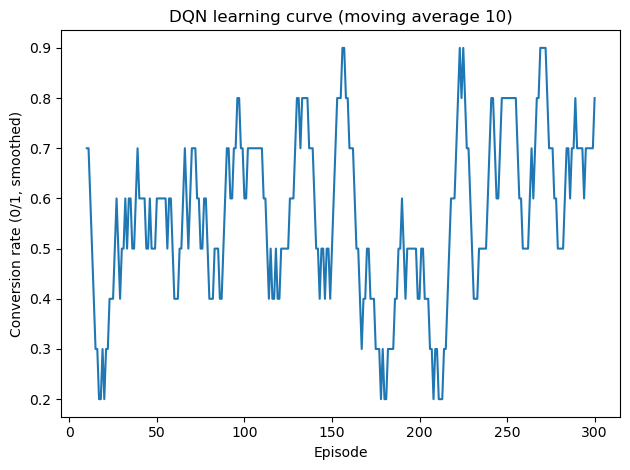

Final 50-episode average conversion: 0.68
Overall average conversion: 0.57


In [9]:
env = ContentPersonalizationEnv(max_steps=8)
qnet = QNetwork(state_dim=7, n_actions=env.action_space.n)

conv_rates, epsilons = run_dqn_training(
    env, qnet,
    n_episodes=300,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    min_buffer_size=500,
    target_update_every=10,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay_episodes=300,
    seed=0
)

plot_learning_curve(conv_rates, window=10)

print("Final 50-episode average conversion:", np.mean(conv_rates[-50:]))
print("Overall average conversion:", np.mean(conv_rates))

#### (3b) Comparison with stable-baselines3

The stable-baselines3 (SB3) DQN implementation includes several engineering improvements compared to the minimal DQN used here. In particular, SB3 applies gradient clipping, carefully tuned learning schedules, and more refined exploration decay, which improve stability and sample efficiency. It also uses optimized training routines and default hyperparameters designed to reduce variance during learning.

Because of these implementation differences, the SB3 learning curve may appear smoother and more stable, and it may converge faster or to a slightly different performance level. In contrast, the minimal DQN here is intentionally simple and therefore more sensitive to stochasticity and hyperparameter choices, which explains the noisier curve.

#### (3c) Interpret the learned policy

(3c1) Early vs late session behaviour

Early in a session (steps 1–3), the agent has little information about the visitor’s latent type, so it benefits from displaying diverse categories to gather signal from clicks. This exploratory behavior helps infer user preferences from observed click patterns.

Later in the session (steps 6–8), once enough click information has accumulated, the agent should exploit what it has learned by selecting assortments that include the visitor’s top-preference categories. This increases the match score used to determine conversion probability. Thus, the learned policy naturally shifts from exploration early to exploitation late within a session.

(3c2) Personalisation vs static policy

The trained DQN achieves a final conversion rate of about 0.68, compared with a lower overall average of 0.57 early in training, indicating that the learned policy improves performance as it adapts to visitor preferences.

A static policy that always displays the same three categories cannot adapt to different visitor types, so it wastes impressions on irrelevant content for many users. In contrast, the DQN personalizes recommendations based on click history, increasing the likelihood that displayed categories match the visitor’s top interests. This improves the match score and therefore the probability of conversion, demonstrating the value of within-session personalization.